In [1]:
# Cell 1: Install required packages
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn

# For M4 Pro Mac, ensure you have MPS (Metal Performance Shaders) support
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

  Using cached pyyaml-6.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached tokenizers-0.22.1-cp39-abi3-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached pyarrow-22.0.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (3.1 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 39.1 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 21.0 MB/s  0:00:00
Using cached hf_xet-1.2.0-cp37-abi3-macosx_11_0_arm64.whl (2.7 MB)
Using cached tokenizers-0.22.1-cp39-abi3-macosx_11_0_arm64.whl (2.9 MB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
Using cached pyarrow-22.0.0-cp31

In [3]:
# Cell 2: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Import from transformers (not torch)
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup  # FIXED: Import from transformers

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set device - M4 Pro uses MPS (Metal Performance Shaders)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Metal Performance Shaders) on M4 Pro")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

/Users/omkarbadadale/.pyenv/versions/3.11.7/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using MPS (Metal Performance Shaders) on M4 Pro
Device: mps


In [4]:
# Cell 3: Load the drug review dataset directly from uploaded files
import pandas as pd

# Load training and test data from uploaded files
df_train = pd.read_csv('data/drugLibTrain_raw.tsv', sep='\t')
df_test = pd.read_csv('data/drugLibTest_raw.tsv', sep='\t')

print(f"Training samples: {len(df_train)}")
print(f"Test samples: {len(df_test)}")

# Combine for custom split later
df = pd.concat([df_train, df_test], ignore_index=True)

print(f"\nTotal samples: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(2))

Training samples: 3107
Test samples: 1036

Total samples: 4143

Columns: ['Unnamed: 0', 'urlDrugName', 'rating', 'effectiveness', 'sideEffects', 'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']

Dataset shape: (4143, 9)

First few rows:
   Unnamed: 0       urlDrugName  rating     effectiveness  \
0        2202         enalapril       4  Highly Effective   
1        3117  ortho-tri-cyclen       1  Highly Effective   

           sideEffects                               condition  \
0    Mild Side Effects  management of congestive heart failure   
1  Severe Side Effects                        birth prevention   

                                      benefitsReview  \
0  slowed the progression of left ventricular dys...   
1  Although this type of birth control has more c...   

                                   sideEffectsReview  \
0  cough, hypotension , proteinuria, impotence , ...   
1  Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...   

                     

In [5]:
# Cell 4: Explore the dataset
print("Dataset Info:")
print(df.info())
print("\n" + "="*70 + "\n")

print("Missing values per column:")
print(df.isnull().sum())
print("\n" + "="*70 + "\n")

print("Rating Distribution:")
print(df['rating'].value_counts().sort_index())
print("\n" + "="*70 + "\n")

print("Effectiveness Distribution:")
print(df['effectiveness'].value_counts())
print("\n" + "="*70 + "\n")

print("Side Effects Distribution:")
print(df['sideEffects'].value_counts())
print("\n" + "="*70 + "\n")

print("Statistical Summary of Ratings:")
print(df['rating'].describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4143 entries, 0 to 4142
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4143 non-null   int64 
 1   urlDrugName        4143 non-null   object
 2   rating             4143 non-null   int64 
 3   effectiveness      4143 non-null   object
 4   sideEffects        4143 non-null   object
 5   condition          4142 non-null   object
 6   benefitsReview     4120 non-null   object
 7   sideEffectsReview  4045 non-null   object
 8   commentsReview     4130 non-null   object
dtypes: int64(2), object(7)
memory usage: 291.4+ KB
None


Missing values per column:
Unnamed: 0            0
urlDrugName           0
rating                0
effectiveness         0
sideEffects           0
condition             1
benefitsReview       23
sideEffectsReview    98
commentsReview       13
dtype: int64


Rating Distribution:
rating
1     420
2     13

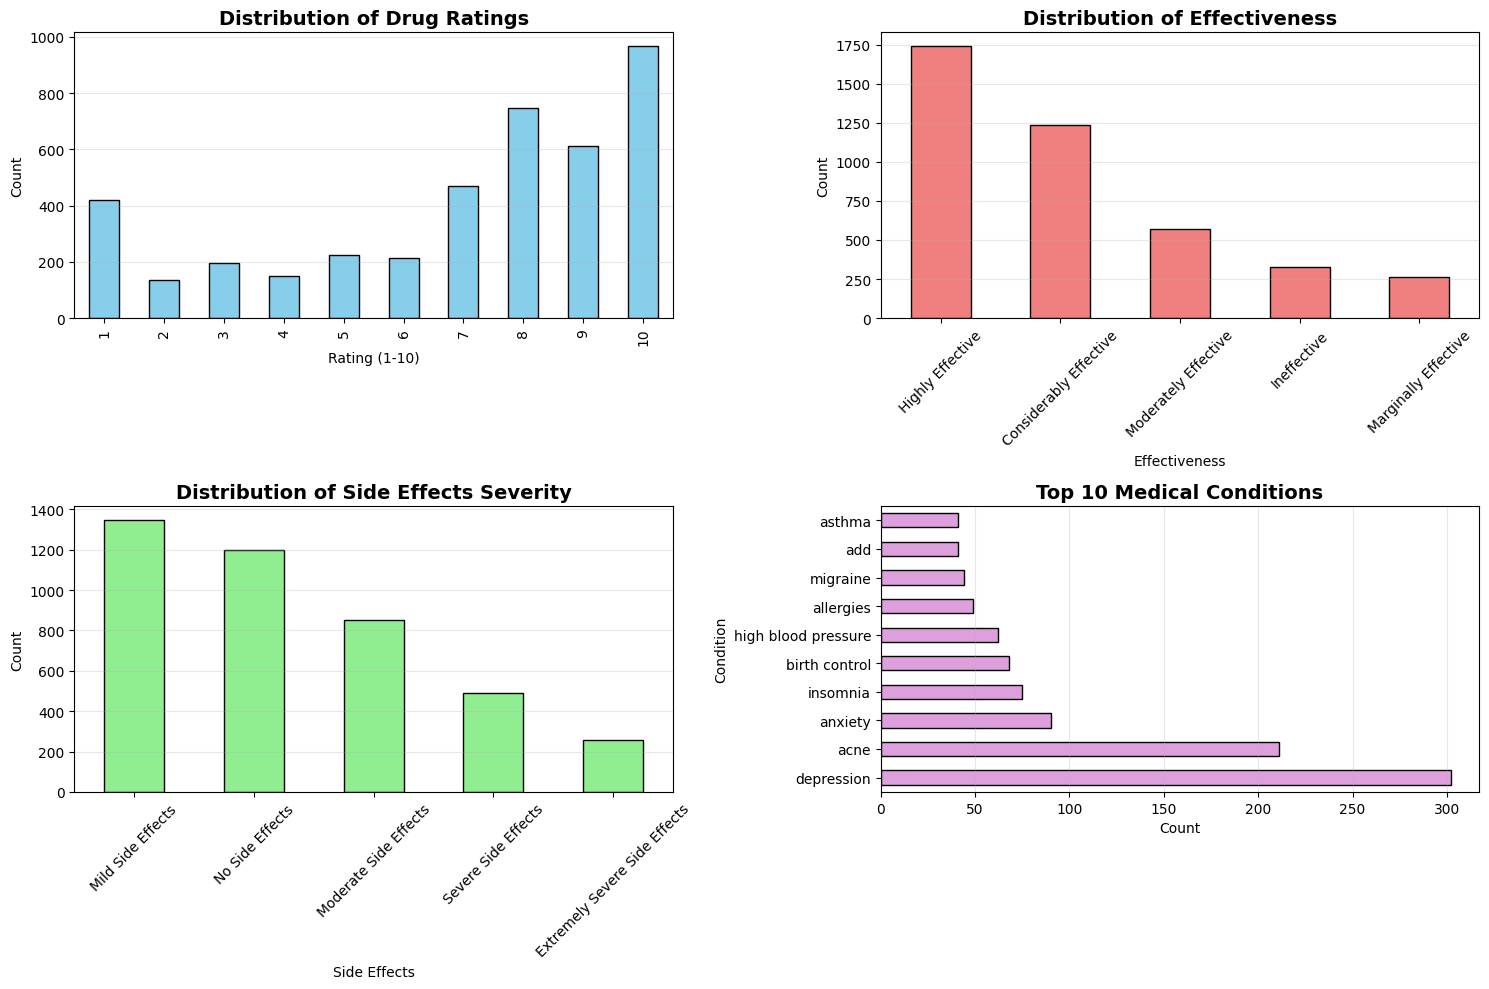


Rating class imbalance:
rating
1     0.101376
2     0.032826
3     0.047067
4     0.036447
5     0.054550
6     0.051895
7     0.113686
8     0.180545
9     0.147960
10    0.233647
Name: proportion, dtype: float64


In [6]:
# Cell 5: Visualize distributions
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Rating distribution
df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Drug Ratings', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Rating (1-10)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(axis='y', alpha=0.3)

# Effectiveness distribution
df['effectiveness'].value_counts().plot(kind='bar', ax=axes[0, 1], color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribution of Effectiveness', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Effectiveness')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Side Effects distribution
df['sideEffects'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribution of Side Effects Severity', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Side Effects')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Top 10 conditions
top_conditions = df['condition'].value_counts().head(10)
top_conditions.plot(kind='barh', ax=axes[1, 1], color='plum', edgecolor='black')
axes[1, 1].set_title('Top 10 Medical Conditions', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Condition')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRating class imbalance:")
print(df['rating'].value_counts(normalize=True).sort_index())

In [7]:
# Cell 6: Examine sample reviews
print("Sample Drug Reviews:")
print("="*80)

for i in range(3):
    print(f"\n--- Sample {i+1} ---")
    print(f"Drug: {df['urlDrugName'].iloc[i]}")
    print(f"Condition: {df['condition'].iloc[i]}")
    print(f"Rating: {df['rating'].iloc[i]}")
    print(f"Effectiveness: {df['effectiveness'].iloc[i]}")
    print(f"Side Effects: {df['sideEffects'].iloc[i]}")
    print(f"\nBenefits: {str(df['benefitsReview'].iloc[i])[:200]}...")
    print(f"\nSide Effects Review: {str(df['sideEffectsReview'].iloc[i])[:200]}...")
    print(f"\nComments: {str(df['commentsReview'].iloc[i])[:200]}...")
    print("-"*80)

Sample Drug Reviews:

--- Sample 1 ---
Drug: enalapril
Condition: management of congestive heart failure
Rating: 4
Effectiveness: Highly Effective
Side Effects: Mild Side Effects

Benefits: slowed the progression of left ventricular dysfunction into overt heart failure 
alone or with other agents in the managment of hypertension 
mangagement of congestive heart failur...

Side Effects Review: cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonitis, tastes disturbances , anusease anorecia , weakness fatigue insominca weakness...

Comments: monitor blood pressure , weight and asses for resolution of fluid...
--------------------------------------------------------------------------------

--- Sample 2 ---
Drug: ortho-tri-cyclen
Condition: birth prevention
Rating: 1
Effectiveness: Highly Effective
Side Effects: Severe Side Effects

Benefits: Although this type of birth control has more cons than pros, it did help with my cramp

In [8]:
# Cell 7: Clean and prepare text data
import re

def clean_text(text):
    """Clean and preprocess review text"""
    if pd.isna(text):
        return ""
    
    # Convert to string
    text = str(text)
    
    # Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text)
    
    # Remove special characters but keep basic punctuation
    text = re.sub(r'[^\w\s.,!?-]', '', text)
    
    # Strip whitespace
    text = text.strip()
    
    return text

# Combine all review columns into one comprehensive text field
df['combined_review'] = (
    df['benefitsReview'].fillna('') + ' ' + 
    df['sideEffectsReview'].fillna('') + ' ' + 
    df['commentsReview'].fillna('')
)

# Clean the combined reviews
df['review_clean'] = df['combined_review'].apply(clean_text)

# Remove rows with very short or empty reviews
df['review_length'] = df['review_clean'].str.len()
df = df[df['review_length'] >= 20].reset_index(drop=True)

print(f"Dataset after removing short reviews: {len(df)} samples")
print(f"\nSample cleaned review:")
print(df['review_clean'].iloc[0][:500])
print(f"\n\nOriginal combined length: {len(df['combined_review'].iloc[0])} characters")
print(f"Cleaned length: {len(df['review_clean'].iloc[0])} characters")

Dataset after removing short reviews: 4142 samples

Sample cleaned review:
slowed the progression of left ventricular dysfunction into overt heart failure alone or with other agents in the managment of hypertension mangagement of congestive heart failur cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonitis, tastes disturbances , anusease anorecia , weakness fatigue insominca weakness monitor blood pressure , weight and asses for resolution of fluid


Original combined length: 448 characters
Cleaned length: 442 characters


Sentiment Distribution:
sentiment
0     902
1     912
2    2328
Name: count, dtype: int64

Percentages:
  Class 0 (Negative): 21.78%
  Class 1 (Neutral): 22.02%
  Class 2 (Positive): 56.20%


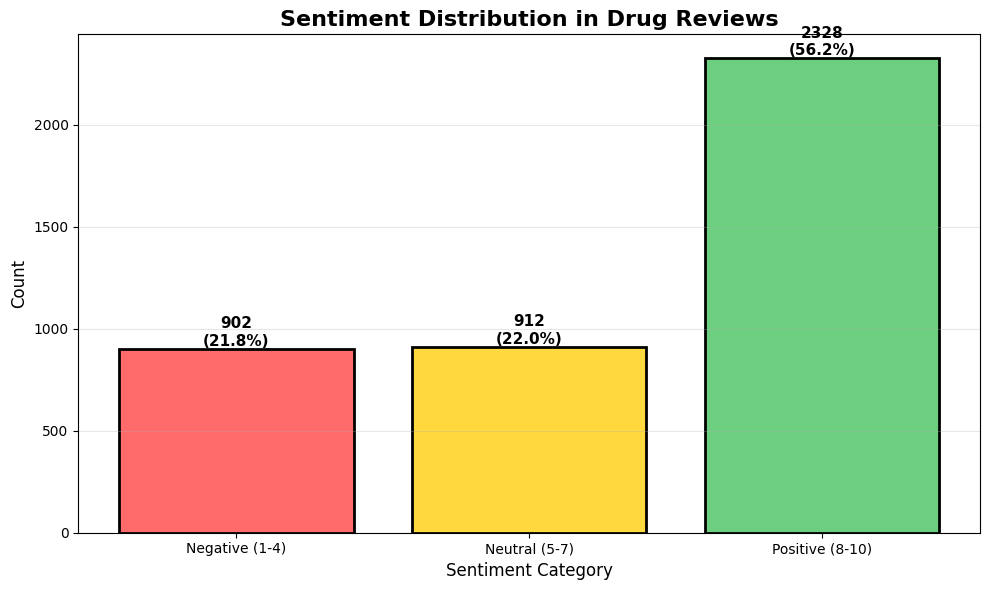


Class Imbalance Analysis:
  Most common class: 2328 samples
  Least common class: 902 samples
  Imbalance ratio: 2.58x


In [9]:
# Cell 8: Convert ratings to sentiment classes
def rating_to_sentiment(rating):
    """Convert 1-10 rating to sentiment class"""
    try:
        rating = int(rating)
        if rating <= 4:
            return 0  # Negative
        elif rating <= 7:
            return 1  # Neutral
        else:  # rating >= 8
            return 2  # Positive
    except:
        return None

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

# Remove any rows with None sentiment
df = df[df['sentiment'].notna()].reset_index(drop=True)
df['sentiment'] = df['sentiment'].astype(int)

print("Sentiment Distribution:")
print(df['sentiment'].value_counts().sort_index())
print("\nPercentages:")
sentiment_dist = df['sentiment'].value_counts(normalize=True).sort_index() * 100
for idx, pct in sentiment_dist.items():
    sentiment_name = ['Negative', 'Neutral', 'Positive'][idx]
    print(f"  Class {idx} ({sentiment_name}): {pct:.2f}%")

# Visualize
plt.figure(figsize=(10, 6))
sentiment_counts = df['sentiment'].value_counts().sort_index()
sentiment_labels = ['Negative (1-4)', 'Neutral (5-7)', 'Positive (8-10)']
colors = ['#ff6b6b', '#ffd93d', '#6bcf7f']

bars = plt.bar(sentiment_labels, sentiment_counts.values, color=colors, edgecolor='black', linewidth=2)
plt.title('Sentiment Distribution in Drug Reviews', fontsize=16, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xlabel('Sentiment Category', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, sentiment_counts.values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nClass Imbalance Analysis:")
print(f"  Most common class: {sentiment_counts.max()} samples")
print(f"  Least common class: {sentiment_counts.min()} samples")
print(f"  Imbalance ratio: {sentiment_counts.max() / sentiment_counts.min():.2f}x")

Review Length Statistics:
count    4142.000000
mean      662.667310
std       426.132133
min        20.000000
25%       381.000000
50%       541.500000
75%       822.000000
max      4452.000000
Name: review_length, dtype: float64

Percentiles:
  25th percentile: 381 characters
  50th percentile: 542 characters
  75th percentile: 822 characters
  90th percentile: 1174 characters
  95th percentile: 1464 characters
  99th percentile: 2226 characters


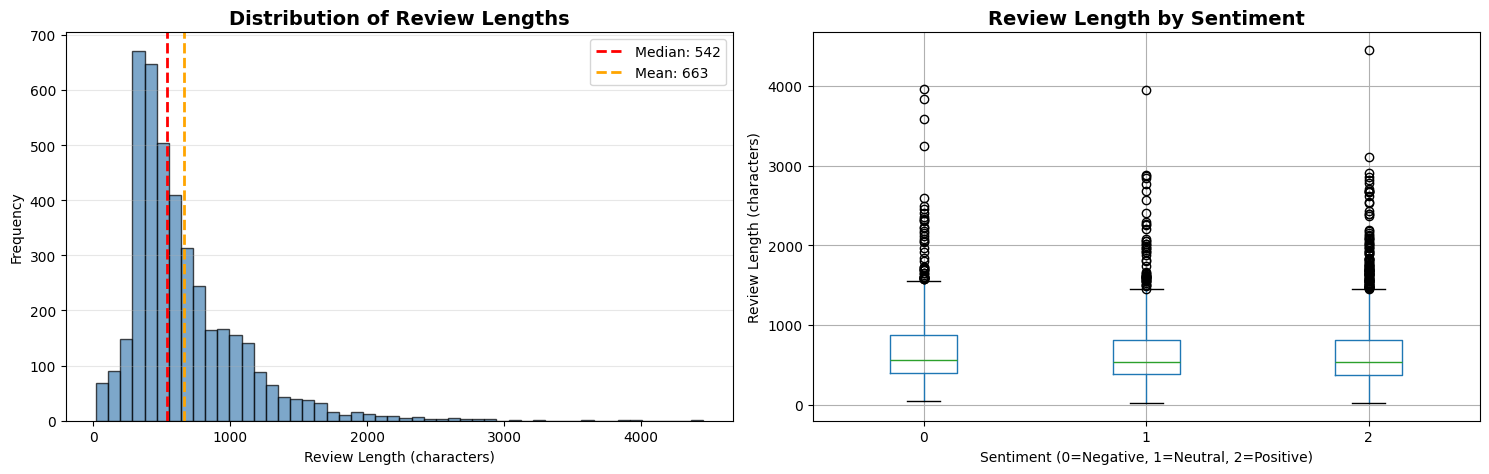


Estimated tokens (length/4.5):
count    4142.000000
mean      147.259402
std        94.696030
min         4.444444
25%        84.666667
50%       120.333333
75%       182.666667
max       989.333333
Name: estimated_tokens, dtype: float64

Reviews likely exceeding 128 tokens: 1865 (45.0%)
Reviews likely exceeding 256 tokens: 453 (10.9%)
Reviews likely exceeding 512 tokens: 38 (0.9%)


In [10]:
# Cell 9: Analyze review lengths for tokenization planning
print("Review Length Statistics:")
print(df['review_length'].describe())
print(f"\nPercentiles:")
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  {p}th percentile: {df['review_length'].quantile(p/100):.0f} characters")

# Visualize review length distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['review_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['review_length'].median(), color='red', linestyle='--', linewidth=2, 
                label=f'Median: {df["review_length"].median():.0f}')
axes[0].axvline(df['review_length'].mean(), color='orange', linestyle='--', linewidth=2, 
                label=f'Mean: {df["review_length"].mean():.0f}')
axes[0].set_title('Distribution of Review Lengths', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Review Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot by sentiment
df.boxplot(column='review_length', by='sentiment', ax=axes[1])
axes[1].set_title('Review Length by Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment (0=Negative, 1=Neutral, 2=Positive)')
axes[1].set_ylabel('Review Length (characters)')
plt.suptitle('')  # Remove auto-title

plt.tight_layout()
plt.show()

# Token length estimation (rough: ~4-5 chars per token for English)
df['estimated_tokens'] = df['review_length'] / 4.5
print(f"\nEstimated tokens (length/4.5):")
print(df['estimated_tokens'].describe())
print(f"\nReviews likely exceeding 128 tokens: {(df['estimated_tokens'] > 128).sum()} ({(df['estimated_tokens'] > 128).sum()/len(df)*100:.1f}%)")
print(f"Reviews likely exceeding 256 tokens: {(df['estimated_tokens'] > 256).sum()} ({(df['estimated_tokens'] > 256).sum()/len(df)*100:.1f}%)")
print(f"Reviews likely exceeding 512 tokens: {(df['estimated_tokens'] > 512).sum()} ({(df['estimated_tokens'] > 512).sum()/len(df)*100:.1f}%)")

Total samples: 4142
Feature (review text) shape: (4142,)
Label (sentiment) shape: (4142,)

Split sizes:
  Train: 2900 (70.0%)
  Validation: 620 (15.0%)
  Test: 622 (15.0%)

Train sentiment distribution:
  Class 0 (Negative): 632 (21.8%)
  Class 1 (Neutral): 638 (22.0%)
  Class 2 (Positive): 1630 (56.2%)

Validation sentiment distribution:
  Class 0 (Negative): 135 (21.8%)
  Class 1 (Neutral): 137 (22.1%)
  Class 2 (Positive): 348 (56.1%)

Test sentiment distribution:
  Class 0 (Negative): 135 (21.7%)
  Class 1 (Neutral): 137 (22.0%)
  Class 2 (Positive): 350 (56.3%)


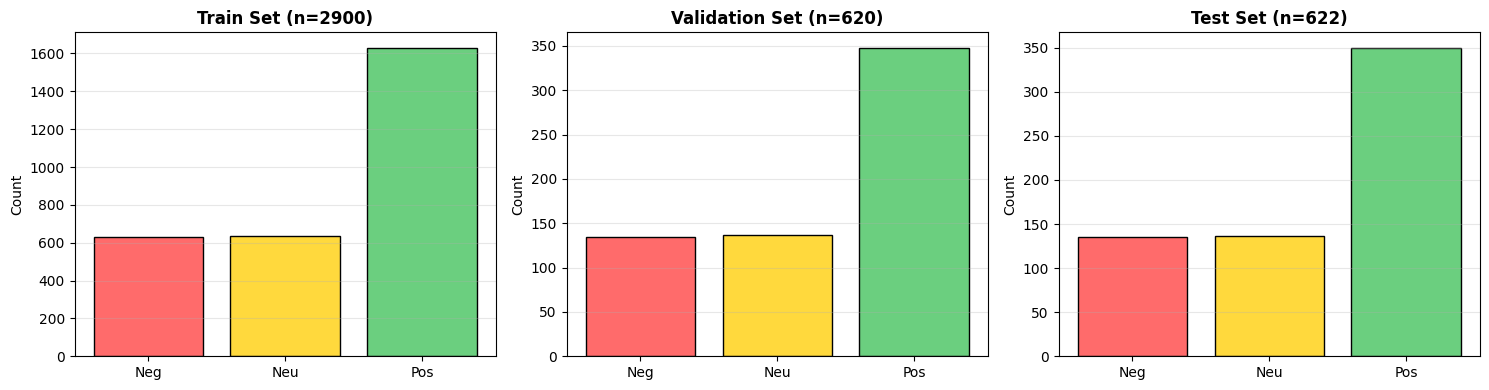

In [11]:
# Cell 10: Create stratified train, validation, and test splits
from sklearn.model_selection import train_test_split

# Extract features and labels
X = df['review_clean'].values
y = df['sentiment'].values

print(f"Total samples: {len(X)}")
print(f"Feature (review text) shape: {X.shape}")
print(f"Label (sentiment) shape: {y.shape}")

# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# Second split: separate train and validation from temp (85% -> 70% train, 15% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED, stratify=y_temp  # 0.176 * 0.85 ≈ 0.15
)

print(f"\nSplit sizes:")
print(f"  Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nTrain sentiment distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    sentiment_name = ['Negative', 'Neutral', 'Positive'][u]
    print(f"  Class {u} ({sentiment_name}): {c} ({c/len(y_train)*100:.1f}%)")

print(f"\nValidation sentiment distribution:")
unique, counts = np.unique(y_val, return_counts=True)
for u, c in zip(unique, counts):
    sentiment_name = ['Negative', 'Neutral', 'Positive'][u]
    print(f"  Class {u} ({sentiment_name}): {c} ({c/len(y_val)*100:.1f}%)")

print(f"\nTest sentiment distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    sentiment_name = ['Negative', 'Neutral', 'Positive'][u]
    print(f"  Class {u} ({sentiment_name}): {c} ({c/len(y_test)*100:.1f}%)")

# Visualize the splits
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
splits = [('Train', y_train), ('Validation', y_val), ('Test', y_test)]
colors = ['#ff6b6b', '#ffd93d', '#6bcf7f']

for idx, (name, data) in enumerate(splits):
    counts = pd.Series(data).value_counts().sort_index()
    axes[idx].bar(['Neg', 'Neu', 'Pos'], counts.values, color=colors, edgecolor='black')
    axes[idx].set_title(f'{name} Set (n={len(data)})', fontweight='bold')
    axes[idx].set_ylabel('Count')
    axes[idx].grid(axis='y', alpha=0.3)
    
plt.tight_layout()
plt.show()

In [12]:
# Cell 11: Calculate class weights for imbalanced dataset (Novel Component #4)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("=" * 70)
print("NOVEL COMPONENT #4: Class-Weighted Loss Function")
print("=" * 70)
print("\nClass weights for handling imbalanced data:")
print("(Higher weights for underrepresented classes)\n")
for i, weight in enumerate(class_weights):
    sentiment_name = ['Negative', 'Neutral', 'Positive'][i]
    class_count = np.sum(y_train == i)
    print(f"  Class {i} ({sentiment_name:8s}): weight={weight:.4f} | samples={class_count}")

print("\n" + "=" * 70)
print("Why this matters:")
print("  - Without weighting: Model ignores minority classes (Negative/Neutral)")
print("  - With weighting: Model learns all classes equally well")
print("  - Critical for medical applications where all sentiments matter!")
print("=" * 70)

NOVEL COMPONENT #4: Class-Weighted Loss Function

Class weights for handling imbalanced data:
(Higher weights for underrepresented classes)

  Class 0 (Negative): weight=1.5295 | samples=632
  Class 1 (Neutral ): weight=1.5152 | samples=638
  Class 2 (Positive): weight=0.5930 | samples=1630

Why this matters:
  - Without weighting: Model ignores minority classes (Negative/Neutral)
  - With weighting: Model learns all classes equally well
  - Critical for medical applications where all sentiments matter!


In [13]:
# Cell 12: Load BioBERT tokenizer and model (Novel Component #1: Fine-tuning pre-trained transformer)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"

print("=" * 70)
print("NOVEL COMPONENT #1: Fine-tuning Pre-trained BioBERT")
print("=" * 70)

print(f"\nLoading BioBERT tokenizer from: {MODEL_NAME}")
print("\n📚 BioBERT Background:")
print("  - Pre-trained on 4.5B words from PubMed abstracts + PMC full-text")
print("  - Understands medical terminology (e.g., 'hypertension', 'angina')")
print("  - Transfer learning: Medical knowledge → Drug sentiment task")
print("  - Published: 2020 by Korea University & DMIS Lab")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"\n🤖 Loading BioBERT model for sequence classification...")
print("  - Adding classification head for 3-class sentiment prediction")
print("  - Head: [CLS] token → Linear(768 → 3) → Softmax")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,  # 3 sentiment classes
    problem_type="single_label_classification"
)

# Move model to device
model = model.to(device)

print(f"\n✅ Model loaded successfully!")
print(f"\n📊 Model Statistics:")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Device: {device}")

print(f"\n🏗️  Architecture:")
print(f"  - BioBERT encoder: 12 transformer layers")
print(f"  - Hidden size: 768")
print(f"  - Attention heads: 12")
print(f"  - Max sequence length: 512 tokens")
print(f"  - Vocabulary size: 28,996 WordPiece tokens")
print(f"  - Classification head: Dense(768 → 3)")

print("\n" + "=" * 70)

NOVEL COMPONENT #1: Fine-tuning Pre-trained BioBERT

Loading BioBERT tokenizer from: dmis-lab/biobert-base-cased-v1.2

📚 BioBERT Background:
  - Pre-trained on 4.5B words from PubMed abstracts + PMC full-text
  - Understands medical terminology (e.g., 'hypertension', 'angina')
  - Transfer learning: Medical knowledge → Drug sentiment task
  - Published: 2020 by Korea University & DMIS Lab

🤖 Loading BioBERT model for sequence classification...
  - Adding classification head for 3-class sentiment prediction
  - Head: [CLS] token → Linear(768 → 3) → Softmax


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✅ Model loaded successfully!

📊 Model Statistics:
  Total parameters: 108,312,579
  Trainable parameters: 108,312,579
  Device: mps

🏗️  Architecture:
  - BioBERT encoder: 12 transformer layers
  - Hidden size: 768
  - Attention heads: 12
  - Max sequence length: 512 tokens
  - Vocabulary size: 28,996 WordPiece tokens
  - Classification head: Dense(768 → 3)



In [14]:
# Cell 13: Create custom Dataset class
from torch.utils.data import Dataset

class DrugReviewDataset(Dataset):
    """Custom PyTorch Dataset for drug reviews with BioBERT tokenization"""
    
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize with BioBERT tokenizer
        # This converts text → WordPiece tokens → token IDs
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,  # Add [CLS] and [SEP] tokens
            max_length=self.max_length,
            padding='max_length',      # Pad to max_length
            truncation=True,           # Truncate if longer
            return_attention_mask=True, # Return attention mask
            return_tensors='pt'        # Return PyTorch tensors
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
# Using 256 tokens - covers 89% of reviews without truncation
MAX_LENGTH = 256

print(f"Creating datasets with MAX_LENGTH={MAX_LENGTH} tokens...")

train_dataset = DrugReviewDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset = DrugReviewDataset(X_val, y_val, tokenizer, MAX_LENGTH)
test_dataset = DrugReviewDataset(X_test, y_test, tokenizer, MAX_LENGTH)

print(f"\n✅ Datasets created:")
print(f"  Train dataset: {len(train_dataset)} samples")
print(f"  Validation dataset: {len(val_dataset)} samples")
print(f"  Test dataset: {len(test_dataset)} samples")

# Test the dataset
print(f"\n🔍 Sample from training dataset:")
sample = train_dataset[0]
print(f"  input_ids shape: {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  label: {sample['label'].item()} ({'Negative' if sample['label'].item()==0 else 'Neutral' if sample['label'].item()==1 else 'Positive'})")

print(f"\n🔤 Tokenization example (first 15 tokens):")
print(f"  Token IDs: {sample['input_ids'][:15].tolist()}")
print(f"  Decoded: {tokenizer.decode(sample['input_ids'][:15])}")
print(f"\n  Special tokens:")
print(f"    [CLS] token ID: {tokenizer.cls_token_id}")
print(f"    [SEP] token ID: {tokenizer.sep_token_id}")
print(f"    [PAD] token ID: {tokenizer.pad_token_id}")

Creating datasets with MAX_LENGTH=256 tokens...

✅ Datasets created:
  Train dataset: 2900 samples
  Validation dataset: 620 samples
  Test dataset: 622 samples

🔍 Sample from training dataset:
  input_ids shape: torch.Size([256])
  attention_mask shape: torch.Size([256])
  label: 2 (Positive)

🔤 Tokenization example (first 15 tokens):
  Token IDs: [101, 176, 19252, 22083, 1394, 1108, 17421, 1106, 1143, 1111, 16516, 15281, 8936, 119, 1606]
  Decoded: [CLS] gabapentin was prescribed to me for bi polar disorder. using

  Special tokens:
    [CLS] token ID: 101
    [SEP] token ID: 102
    [PAD] token ID: 0


In [15]:
# Cell 14: Create DataLoaders
from torch.utils.data import DataLoader

BATCH_SIZE = 16  # Good balance for M4 Pro (can try 8, 16, or 32)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Must be 0 for Mac MPS
    pin_memory=False  # MPS doesn't support pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"✅ DataLoaders created:")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")
print(f"  Batch size: {BATCH_SIZE}")

# Test loading a batch
print(f"\n🔍 Testing batch loading...")
for batch in train_loader:
    print(f"  Batch input_ids shape: {batch['input_ids'].shape}")
    print(f"  Batch attention_mask shape: {batch['attention_mask'].shape}")
    print(f"  Batch labels shape: {batch['label'].shape}")
    print(f"\n  Interpretation:")
    print(f"    - {batch['input_ids'].shape[0]} reviews in this batch")
    print(f"    - Each tokenized to {batch['input_ids'].shape[1]} tokens")
    break

print(f"\n📊 Training configuration:")
print(f"  Total training steps per epoch: {len(train_loader)}")
print(f"  Total batches to process: {len(train_loader) * 3} (for 3 epochs)")

✅ DataLoaders created:
  Training batches: 182
  Validation batches: 39
  Test batches: 39
  Batch size: 16

🔍 Testing batch loading...
  Batch input_ids shape: torch.Size([16, 256])
  Batch attention_mask shape: torch.Size([16, 256])
  Batch labels shape: torch.Size([16])

  Interpretation:
    - 16 reviews in this batch
    - Each tokenized to 256 tokens

📊 Training configuration:
  Total training steps per epoch: 182
  Total batches to process: 546 (for 3 epochs)


In [16]:
# Cell 15: Setup optimizer, scheduler, and loss function
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch.nn as nn

# Hyperparameters
LEARNING_RATE = 2e-5  # Very low LR for fine-tuning (avoid catastrophic forgetting)
WEIGHT_DECAY = 0.01   # L2 regularization
EPOCHS = 3            # Typical for BERT fine-tuning (3-5 epochs)

print("=" * 70)
print("NOVEL COMPONENTS #2 & #3: Optimizer & LR Scheduling")
print("=" * 70)

# Novel Component 2: AdamW optimizer with weight decay
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eps=1e-8,
    betas=(0.9, 0.999)
)

print(f"\n✅ AdamW Optimizer configured:")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Why AdamW?")
print(f"    - Decoupled weight decay (better than L2)")
print(f"    - Standard for transformer fine-tuning")
print(f"    - Handles sparse gradients well")

# Novel Component 3: Learning rate scheduler with warmup
total_steps = len(train_loader) * EPOCHS
WARMUP_STEPS = int(0.1 * total_steps)  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"\n✅ Linear Warmup Scheduler configured:")
print(f"  Total training steps: {total_steps}")
print(f"  Warmup steps: {WARMUP_STEPS} (10%)")
print(f"  Why warmup + decay?")
print(f"    - Warmup: Gradually increase LR (0 → 2e-5)")
print(f"    - Prevents early training instability")
print(f"    - Linear decay after warmup")
print(f"    - Helps preserve pre-trained weights")

# Loss function with class weights (Novel Component 4)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"\n✅ Weighted CrossEntropyLoss configured:")
print(f"  Using class weights: {class_weights.round(4)}")
print(f"  Why weighted loss?")
print(f"    - Handles 2.58x class imbalance")
print(f"    - Prevents bias toward majority class (Positive)")
print(f"    - Ensures model learns all sentiments")

print(f"\n📋 Training Summary:")
print(f"  Device: {device}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Steps per epoch: {len(train_loader)}")
print(f"  Total steps: {total_steps}")
print(f"  Initial LR: {LEARNING_RATE}")
print(f"  Final LR: ~0 (linear decay)")

print("\n" + "=" * 70)

NOVEL COMPONENTS #2 & #3: Optimizer & LR Scheduling

✅ AdamW Optimizer configured:
  Learning rate: 2e-05
  Weight decay: 0.01
  Why AdamW?
    - Decoupled weight decay (better than L2)
    - Standard for transformer fine-tuning
    - Handles sparse gradients well

✅ Linear Warmup Scheduler configured:
  Total training steps: 546
  Warmup steps: 54 (10%)
  Why warmup + decay?
    - Warmup: Gradually increase LR (0 → 2e-5)
    - Prevents early training instability
    - Linear decay after warmup
    - Helps preserve pre-trained weights

✅ Weighted CrossEntropyLoss configured:
  Using class weights: [1.5295 1.5152 0.593 ]
  Why weighted loss?
    - Handles 2.58x class imbalance
    - Prevents bias toward majority class (Positive)
    - Ensures model learns all sentiments

📋 Training Summary:
  Device: mps
  Epochs: 3
  Batch size: 16
  Steps per epoch: 182
  Total steps: 546
  Initial LR: 2e-05
  Final LR: ~0 (linear decay)



In [17]:
# Cell 16: Define training function
def train_epoch(model, data_loader, optimizer, scheduler, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    predictions = []
    true_labels = []
    
    for batch_idx, batch in enumerate(data_loader):
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        logits = outputs.logits
        
        # Calculate loss (with class weights)
        loss = criterion(logits, labels)
        
        # Backward pass
        loss.backward()
        
        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update weights
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(labels.cpu().numpy())
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"  Batch {batch_idx + 1}/{len(data_loader)} | Loss: {loss.item():.4f} | LR: {current_lr:.2e}")
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')
    
    return avg_loss, accuracy, f1

print("✅ Training function defined")

✅ Training function defined


In [18]:
# Cell 17: Define evaluation function
def evaluate(model, data_loader, criterion, device):
    """Evaluate the model"""
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            # Forward pass
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            logits = outputs.logits
            
            # Calculate loss
            loss = criterion(logits, labels)
            
            # Track metrics
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')
    
    return avg_loss, accuracy, f1, predictions, true_labels

print("✅ Evaluation function defined")

✅ Evaluation function defined


In [19]:
# Cell 18: Train the model
import time

# Track metrics
history = {
    'train_loss': [],
    'train_acc': [],
    'train_f1': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'learning_rates': []
}

best_val_f1 = 0
best_model_state = None

print("=" * 80)
print(" " * 25 + "🚀 TRAINING BIOBERT 🚀")
print("=" * 80)
print(f"\nConfiguration:")
print(f"  Model: BioBERT-base (108M parameters)")
print(f"  Task: 3-class drug sentiment classification")
print(f"  Training samples: {len(X_train)}")
print(f"  Validation samples: {len(X_val)}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Device: {device}")
print(f"\n" + "=" * 80 + "\n")

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"{'='*80}")
    print(f"EPOCH {epoch + 1}/{EPOCHS}")
    print(f"{'='*80}")
    
    # Train
    epoch_start = time.time()
    print(f"\n📚 Training...")
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )
    
    # Validate
    print(f"\n🔍 Validating...")
    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, device
    )
    
    epoch_time = time.time() - epoch_start
    
    # Store metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['learning_rates'].append(scheduler.get_last_lr()[0])
    
    # Print epoch results
    print(f"\n{'─'*80}")
    print(f"📊 EPOCH {epoch + 1} RESULTS (Time: {epoch_time/60:.2f} min)")
    print(f"{'─'*80}")
    print(f"  Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
    
    # Check for improvement
    improvement = val_f1 - best_val_f1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
        print(f"  ✅ NEW BEST MODEL! (F1: {best_val_f1:.4f}, +{improvement:.4f})")
    else:
        print(f"  ⚠️  No improvement (Best F1: {best_val_f1:.4f})")
    
    print(f"{'─'*80}\n")

training_time = time.time() - start_time

# Load best model
model.load_state_dict(best_model_state)

print(f"\n{'='*80}")
print(f" " * 30 + "✅ TRAINING COMPLETE!")
print(f"{'='*80}")
print(f"  Total time: {training_time/60:.2f} minutes")
print(f"  Best validation F1: {best_val_f1:.4f}")
print(f"  Final learning rate: {scheduler.get_last_lr()[0]:.2e}")
print(f"{'='*80}\n")

                         🚀 TRAINING BIOBERT 🚀

Configuration:
  Model: BioBERT-base (108M parameters)
  Task: 3-class drug sentiment classification
  Training samples: 2900
  Validation samples: 620
  Epochs: 3
  Batch size: 16
  Learning rate: 2e-05
  Device: mps


EPOCH 1/3

📚 Training...
  Batch 50/182 | Loss: 1.0830 | LR: 1.85e-05
  Batch 100/182 | Loss: 0.8534 | LR: 1.81e-05
  Batch 150/182 | Loss: 0.8848 | LR: 1.61e-05

🔍 Validating...

────────────────────────────────────────────────────────────────────────────────
📊 EPOCH 1 RESULTS (Time: 2.18 min)
────────────────────────────────────────────────────────────────────────────────
  Train → Loss: 1.0152 | Acc: 0.4455 | F1: 0.4300
  Val   → Loss: 0.8730 | Acc: 0.6387 | F1: 0.5954
  ✅ NEW BEST MODEL! (F1: 0.5954, +0.5954)
────────────────────────────────────────────────────────────────────────────────

EPOCH 2/3

📚 Training...
  Batch 50/182 | Loss: 0.4710 | LR: 1.28e-05
  Batch 100/182 | Loss: 0.7755 | LR: 1.07e-05
  Batch 150/182 

📊 Training curves saved as 'training_history.png'


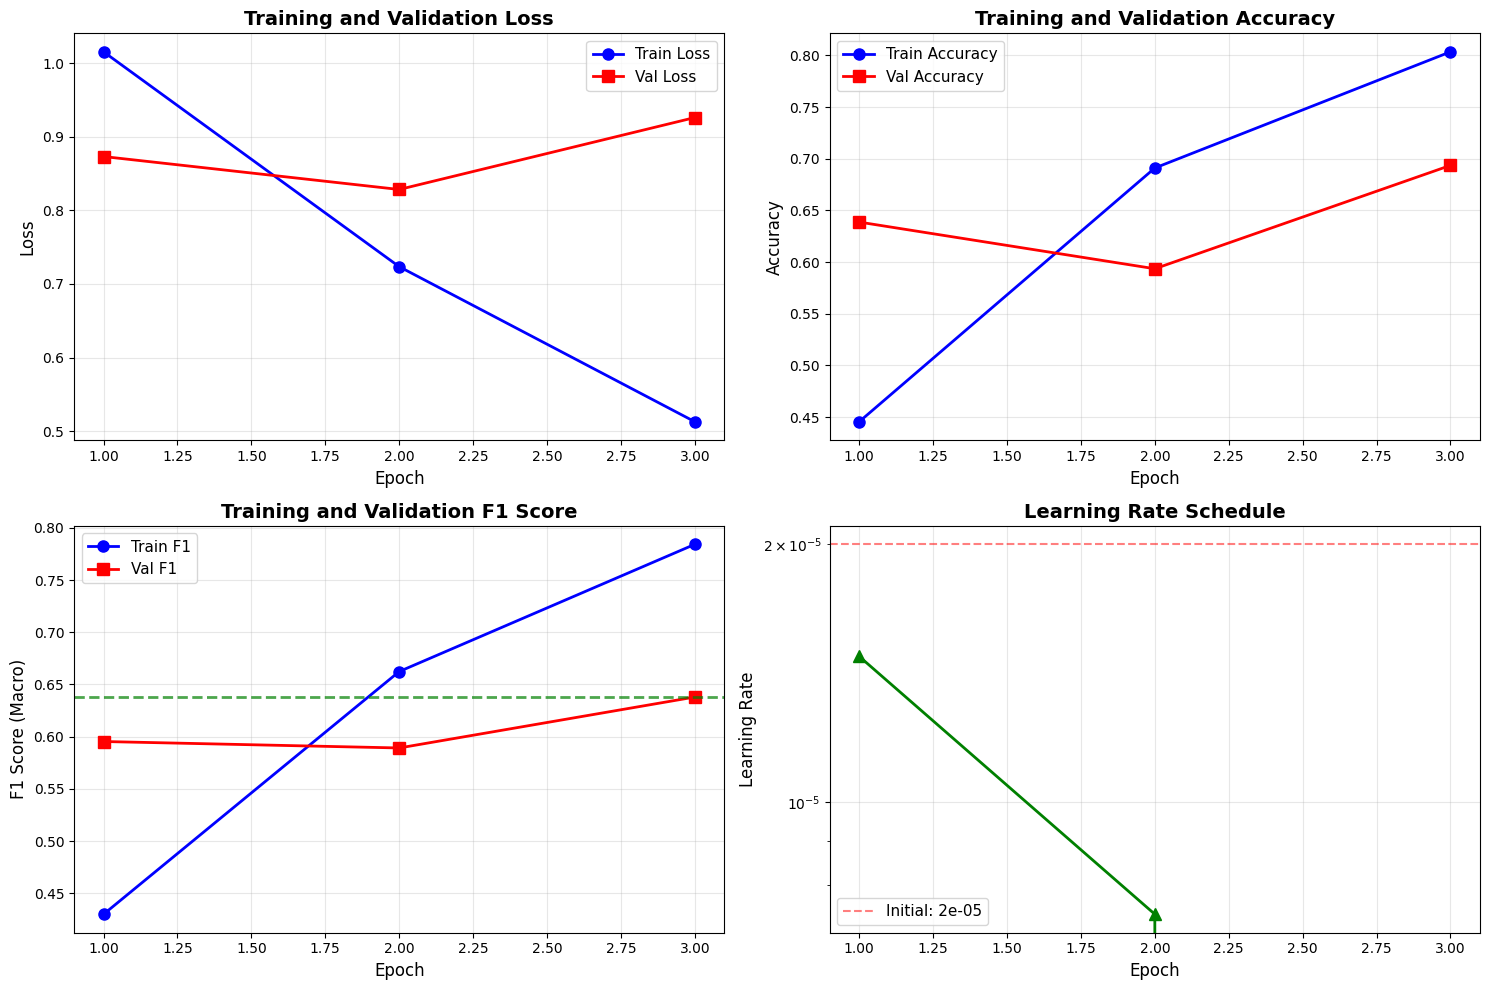


TRAINING SUMMARY TABLE
 Epoch Train Loss Val Loss Train Acc Val Acc Train F1 Val F1
     1     1.0152   0.8730    0.4455  0.6387   0.4300 0.5954
     2     0.7235   0.8283    0.6910  0.5935   0.6624 0.5892
     3     0.5129   0.9260    0.8034  0.6935   0.7842 0.6380


In [20]:
# Cell 19: Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=8)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=8)
axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2, markersize=8)
axes[0, 1].plot(epochs_range, history['val_acc'], 'r-s', label='Val Accuracy', linewidth=2, markersize=8)
axes[0, 1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(alpha=0.3)

# F1 Score
axes[1, 0].plot(epochs_range, history['train_f1'], 'b-o', label='Train F1', linewidth=2, markersize=8)
axes[1, 0].plot(epochs_range, history['val_f1'], 'r-s', label='Val F1', linewidth=2, markersize=8)
axes[1, 0].set_title('Training and Validation F1 Score', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('F1 Score (Macro)', fontsize=12)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].axhline(y=best_val_f1, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Best: {best_val_f1:.4f}')

# Learning Rate
axes[1, 1].plot(epochs_range, history['learning_rates'], 'g-^', linewidth=2, markersize=8)
axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
axes[1, 1].set_yscale('log')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].axhline(y=LEARNING_RATE, color='red', linestyle='--', alpha=0.5, label=f'Initial: {LEARNING_RATE:.0e}')
axes[1, 1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
print("📊 Training curves saved as 'training_history.png'")
plt.show()

# Print summary table
print("\n" + "="*60)
print("TRAINING SUMMARY TABLE")
print("="*60)
summary_df = pd.DataFrame({
    'Epoch': list(range(1, EPOCHS + 1)),
    'Train Loss': [f"{x:.4f}" for x in history['train_loss']],
    'Val Loss': [f"{x:.4f}" for x in history['val_loss']],
    'Train Acc': [f"{x:.4f}" for x in history['train_acc']],
    'Val Acc': [f"{x:.4f}" for x in history['val_acc']],
    'Train F1': [f"{x:.4f}" for x in history['train_f1']],
    'Val F1': [f"{x:.4f}" for x in history['val_f1']]
})
print(summary_df.to_string(index=False))
print("="*60)

In [21]:
# Cell 20: Final evaluation on test set
print("\n" + "="*80)
print(" " * 25 + "🎯 FINAL TEST EVALUATION")
print("="*80)

print("\nEvaluating best model on held-out test set...\n")

test_loss, test_acc, test_f1, test_preds, test_true = evaluate(
    model, test_loader, criterion, device
)

print("="*80)
print("TEST SET RESULTS")
print("="*80)
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Macro F1: {test_f1:.4f}")
print("="*80)


                         🎯 FINAL TEST EVALUATION

Evaluating best model on held-out test set...

TEST SET RESULTS
  Loss: 0.7873
  Accuracy: 0.6913 (69.13%)
  Macro F1: 0.6533


In [22]:
# Cell 21: Detailed classification report
from sklearn.metrics import classification_report, precision_recall_fscore_support

class_names = ['Negative', 'Neutral', 'Positive']

print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(test_true, test_preds, target_names=class_names, digits=4))

# Get per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    test_true, test_preds, average=None
)

# Create results table
results_df = pd.DataFrame({
    'Class': class_names,
    'Precision': [f"{p:.4f}" for p in precision],
    'Recall': [f"{r:.4f}" for r in recall],
    'F1-Score': [f"{f:.4f}" for f in f1],
    'Support': support
})

print("\n" + "="*80)
print("PER-CLASS METRICS TABLE")
print("="*80)
print(results_df.to_string(index=False))

# Overall metrics
print("\n" + "="*80)
print("OVERALL METRICS")
print("="*80)
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Macro-averaged Precision: {precision.mean():.4f}")
print(f"  Macro-averaged Recall: {recall.mean():.4f}")
print(f"  Macro-averaged F1: {test_f1:.4f}")
print("="*80)


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.7557    0.7333    0.7444       135
     Neutral     0.4025    0.4672    0.4324       137
    Positive     0.8042    0.7629    0.7830       350

    accuracy                         0.6913       622
   macro avg     0.6542    0.6544    0.6533       622
weighted avg     0.7052    0.6913    0.6974       622


PER-CLASS METRICS TABLE
   Class Precision Recall F1-Score  Support
Negative    0.7557 0.7333   0.7444      135
 Neutral    0.4025 0.4672   0.4324      137
Positive    0.8042 0.7629   0.7830      350

OVERALL METRICS
  Accuracy: 0.6913
  Macro-averaged Precision: 0.6542
  Macro-averaged Recall: 0.6544
  Macro-averaged F1: 0.6533


📊 Confusion matrix saved as 'confusion_matrix.png'


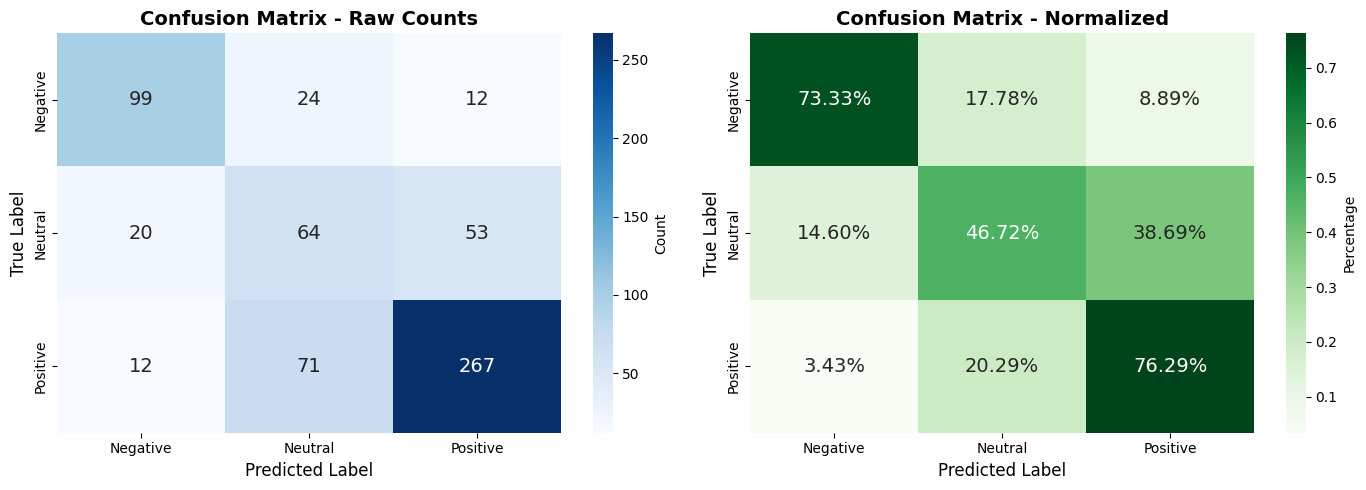


CONFUSION MATRIX ANALYSIS

Negative:
  Correctly classified: 99/135 (73.3%)
  Most confused with: Neutral (24 times)

Neutral:
  Correctly classified: 64/137 (46.7%)
  Most confused with: Positive (53 times)

Positive:
  Correctly classified: 267/350 (76.3%)
  Most confused with: Neutral (71 times)


In [23]:
# Cell 22: Generate and plot confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_true, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=axes[0], annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Normalized (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'}, ax=axes[1], annot_kws={'size': 14})
axes[1].set_title('Confusion Matrix - Normalized', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("📊 Confusion matrix saved as 'confusion_matrix.png'")
plt.show()

# Analyze confusion matrix
print("\n" + "="*80)
print("CONFUSION MATRIX ANALYSIS")
print("="*80)
for i, class_name in enumerate(class_names):
    correct = cm[i, i]
    total = cm[i].sum()
    accuracy = correct / total * 100
    print(f"\n{class_name}:")
    print(f"  Correctly classified: {correct}/{total} ({accuracy:.1f}%)")
    
    # Find most common misclassification
    misclass = cm[i].copy()
    misclass[i] = 0
    if misclass.sum() > 0:
        most_confused_with = np.argmax(misclass)
        count = misclass[most_confused_with]
        print(f"  Most confused with: {class_names[most_confused_with]} ({count} times)")
print("="*80)

In [24]:
# Cell 23: Analyze misclassified examples
print("=" * 80)
print("ERROR ANALYSIS: Examining Misclassifications")
print("=" * 80)

# Find misclassified examples
misclassified_indices = [i for i, (true, pred) in enumerate(zip(test_true, test_preds)) if true != pred]
correct_indices = [i for i, (true, pred) in enumerate(zip(test_true, test_preds)) if true == pred]

print(f"\nTotal misclassifications: {len(misclassified_indices)} out of {len(test_true)}")
print(f"Error rate: {len(misclassified_indices)/len(test_true)*100:.2f}%")
print(f"Correct predictions: {len(correct_indices)} ({len(correct_indices)/len(test_true)*100:.2f}%)")

# Analyze misclassifications by type
class_names = ['Negative', 'Neutral', 'Positive']
misclass_types = {}

for idx in misclassified_indices:
    true_label = class_names[test_true[idx]]
    pred_label = class_names[test_preds[idx]]
    key = f"{true_label} → {pred_label}"
    if key not in misclass_types:
        misclass_types[key] = []
    misclass_types[key].append(idx)

print(f"\nMisclassification patterns:")
for pattern, indices in sorted(misclass_types.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"  {pattern}: {len(indices)} cases ({len(indices)/len(misclassified_indices)*100:.1f}%)")

# Show examples of each misclassification type
print("\n" + "=" * 80)
print("EXAMPLE MISCLASSIFICATIONS")
print("=" * 80)

for pattern, indices in sorted(misclass_types.items(), key=lambda x: len(x[1]), reverse=True)[:3]:
    print(f"\n{'─'*80}")
    print(f"Pattern: {pattern} ({len(indices)} cases)")
    print(f"{'─'*80}")
    
    # Show first 2 examples of this pattern
    for i, idx in enumerate(indices[:2]):
        review = X_test[idx]
        true_label = class_names[test_true[idx]]
        pred_label = class_names[test_preds[idx]]
        
        print(f"\nExample {i+1}:")
        print(f"  Review: {review[:300]}...")
        print(f"  True Label: {true_label}")
        print(f"  Predicted Label: {pred_label}")
        print(f"  Analysis: ", end="")
        
        # Provide analysis based on pattern
        if "Neutral → Positive" in pattern:
            print("Review may contain positive keywords that outweighed neutral sentiment")
        elif "Neutral → Negative" in pattern:
            print("Review may contain negative side effects that outweighed benefits")
        elif "Positive → Neutral" in pattern:
            print("Review may have mixed sentiments or caveats that lowered classification")
        elif "Negative → Neutral" in pattern:
            print("Review may acknowledge some benefits despite overall negativity")
        elif "Positive → Negative" in pattern:
            print("Severe misclassification - review likely has confusing language")
        elif "Negative → Positive" in pattern:
            print("Severe misclassification - review likely has confusing language")
        
        print()

ERROR ANALYSIS: Examining Misclassifications

Total misclassifications: 192 out of 622
Error rate: 30.87%
Correct predictions: 430 (69.13%)

Misclassification patterns:
  Positive → Neutral: 71 cases (37.0%)
  Neutral → Positive: 53 cases (27.6%)
  Negative → Neutral: 24 cases (12.5%)
  Neutral → Negative: 20 cases (10.4%)
  Positive → Negative: 12 cases (6.2%)
  Negative → Positive: 12 cases (6.2%)

EXAMPLE MISCLASSIFICATIONS

────────────────────────────────────────────────────────────────────────────────
Pattern: Positive → Neutral (71 cases)
────────────────────────────────────────────────────────────────────────────────

Example 1:
  Review: Less aggrivation,less anxiety,less worrying,less overall depression. Irritability at times and difficulty sleeping,heart palpitations and some sexual dysfunction. I have had post-partum depression severely with each of my children.I have 3. In addition to the Bi-Polar disorder I have lived with most...
  True Label: Positive
  Predicted Label:

Calculating prediction confidence scores...

PREDICTION CONFIDENCE ANALYSIS

Confidence Statistics:
  Mean confidence: 0.7894
  Median confidence: 0.8258
  Std deviation: 0.1375
  Min confidence: 0.4114
  Max confidence: 0.9735

Confidence by Prediction Correctness:
  Correct predictions: 0.8306 ± 0.1170
  Incorrect predictions: 0.6970 ± 0.1350
  Difference: 0.1336

📊 Confidence plot saved as 'prediction_confidence.png'


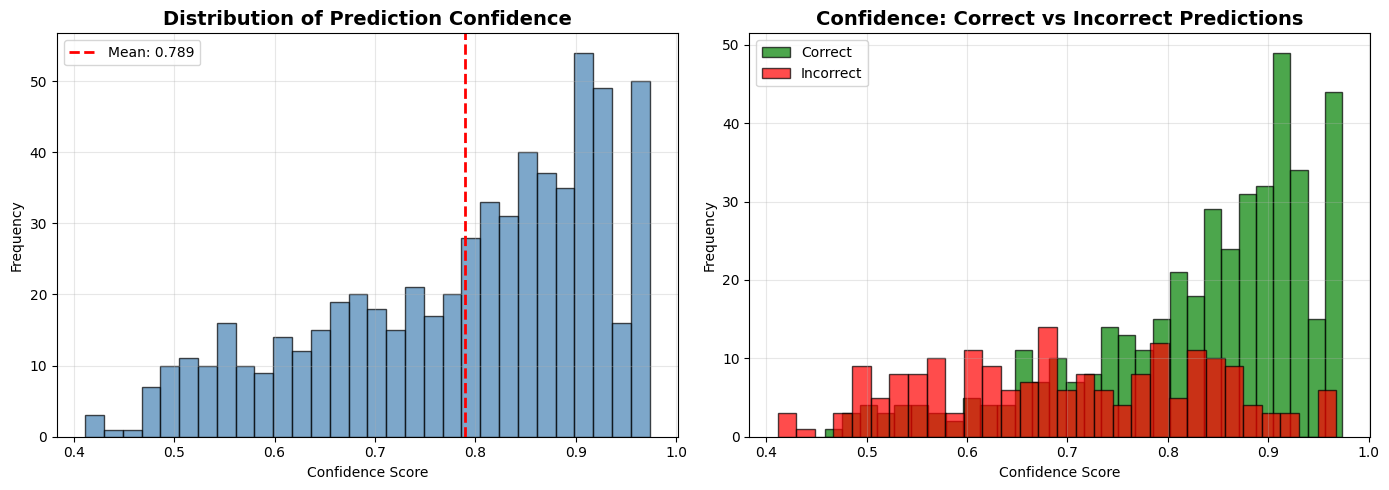


HIGH CONFIDENCE PREDICTIONS

✅ High Confidence CORRECT Predictions:

1. Confidence: 0.9735
   True Label: Negative
   Review: There were no benefits of taking this medicine unless you count the fact that now I know I should NEVER take this medicine again. Im severely allergic to it. Swelling of the face, tingling, itchy eyes...
   Probabilities: Neg=0.974, Neu=0.020, Pos=0.006

2. Confidence: 0.9725
   True Label: Negative
   Review: none Within 30 minutes of taking my first dose of imitrex on Christmas eve when I felt the onset of my migraine, I began to feel a heavy, cramping feeling in my muscles like I had slept the wrong way....
   Probabilities: Neg=0.972, Neu=0.022, Pos=0.006

3. Confidence: 0.9720
   True Label: Negative
   Review: it did clear up my uti but not worth feeling like I did after taking this drug. severe headache, chills, fever, I literally thought I was going to die. I took the drug as prescribed with food and afte...
   Probabilities: Neg=0.972, Neu=0.022, Pos=0

In [25]:
# Cell 24: Analyze prediction confidence
import torch.nn.functional as F

def predict_with_confidence(model, data_loader, device):
    """Get predictions with confidence scores"""
    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probs = F.softmax(logits, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_probs), np.array(all_preds), np.array(all_labels)

print("Calculating prediction confidence scores...")
test_probs, test_preds_conf, test_labels_conf = predict_with_confidence(model, test_loader, device)

# Get confidence (max probability) for each prediction
confidences = np.max(test_probs, axis=1)

print("\n" + "=" * 80)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 80)

print(f"\nConfidence Statistics:")
print(f"  Mean confidence: {confidences.mean():.4f}")
print(f"  Median confidence: {np.median(confidences):.4f}")
print(f"  Std deviation: {confidences.std():.4f}")
print(f"  Min confidence: {confidences.min():.4f}")
print(f"  Max confidence: {confidences.max():.4f}")

# Analyze confidence for correct vs incorrect predictions
correct_mask = test_preds_conf == test_labels_conf
correct_confidences = confidences[correct_mask]
incorrect_confidences = confidences[~correct_mask]

print(f"\nConfidence by Prediction Correctness:")
print(f"  Correct predictions: {correct_confidences.mean():.4f} ± {correct_confidences.std():.4f}")
print(f"  Incorrect predictions: {incorrect_confidences.mean():.4f} ± {incorrect_confidences.std():.4f}")
print(f"  Difference: {correct_confidences.mean() - incorrect_confidences.mean():.4f}")

# Visualize confidence distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall confidence distribution
axes[0].hist(confidences, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(confidences.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {confidences.mean():.3f}')
axes[0].set_title('Distribution of Prediction Confidence', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confidence by correctness
axes[1].hist(correct_confidences, bins=30, alpha=0.7, label='Correct', color='green', edgecolor='black')
axes[1].hist(incorrect_confidences, bins=30, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
axes[1].set_title('Confidence: Correct vs Incorrect Predictions', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_confidence.png', dpi=300, bbox_inches='tight')
print("\n📊 Confidence plot saved as 'prediction_confidence.png'")
plt.show()

# Show high confidence correct and incorrect predictions
print("\n" + "=" * 80)
print("HIGH CONFIDENCE PREDICTIONS")
print("=" * 80)

# Top 3 high confidence correct predictions
print("\n✅ High Confidence CORRECT Predictions:")
correct_indices = np.where(correct_mask)[0]
correct_conf_sorted = np.argsort(confidences[correct_indices])[-3:][::-1]

for i, idx in enumerate(correct_conf_sorted):
    actual_idx = correct_indices[idx]
    print(f"\n{i+1}. Confidence: {confidences[actual_idx]:.4f}")
    print(f"   True Label: {class_names[test_labels_conf[actual_idx]]}")
    print(f"   Review: {X_test[actual_idx][:200]}...")
    print(f"   Probabilities: Neg={test_probs[actual_idx][0]:.3f}, Neu={test_probs[actual_idx][1]:.3f}, Pos={test_probs[actual_idx][2]:.3f}")

# Top 3 high confidence incorrect predictions
print("\n❌ High Confidence INCORRECT Predictions (Model's mistakes):")
incorrect_indices = np.where(~correct_mask)[0]
incorrect_conf_sorted = np.argsort(confidences[incorrect_indices])[-3:][::-1]

for i, idx in enumerate(incorrect_conf_sorted):
    actual_idx = incorrect_indices[idx]
    print(f"\n{i+1}. Confidence: {confidences[actual_idx]:.4f}")
    print(f"   True Label: {class_names[test_labels_conf[actual_idx]]}")
    print(f"   Predicted Label: {class_names[test_preds_conf[actual_idx]]}")
    print(f"   Review: {X_test[actual_idx][:200]}...")
    print(f"   Probabilities: Neg={test_probs[actual_idx][0]:.3f}, Neu={test_probs[actual_idx][1]:.3f}, Pos={test_probs[actual_idx][2]:.3f}")

In [26]:
# Cell 25: Test the model on new drug reviews (inference demo)
def predict_sentiment(text, model, tokenizer, device, max_length=256):
    """Predict sentiment for a new review"""
    model.eval()
    
    # Clean text
    text_clean = clean_text(text)
    
    # Tokenize
    encoding = tokenizer(
        text_clean,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = F.softmax(logits, dim=1)
        pred = torch.argmax(logits, dim=1).item()
    
    sentiment = class_names[pred]
    confidence = probs[0][pred].item()
    
    return sentiment, confidence, probs[0].cpu().numpy()

# Create test examples
test_examples = [
    "This medication completely changed my life! No side effects and highly effective for my condition. I feel like a new person.",
    
    "The drug works okay but gives me terrible headaches and nausea. Not sure if the benefits outweigh the side effects.",
    
    "Absolutely horrible experience. Made my symptoms worse and caused severe allergic reactions. Do NOT recommend!",
    
    "It helps a little bit with the pain, but not as much as I hoped. Some mild dizziness but nothing too serious.",
    
    "After taking this for 6 months, my blood pressure is finally under control. Minimal side effects and very effective."
]

print("=" * 80)
print("INFERENCE ON NEW DRUG REVIEWS")
print("=" * 80)

for i, review in enumerate(test_examples):
    print(f"\n{'─'*80}")
    print(f"Example {i+1}:")
    print(f"{'─'*80}")
    
    sentiment, confidence, probs = predict_sentiment(review, model, tokenizer, device)
    
    print(f"Review: {review}")
    print(f"\n🎯 Prediction: {sentiment}")
    print(f"📊 Confidence: {confidence:.2%}")
    print(f"📈 Class Probabilities:")
    print(f"   • Negative: {probs[0]:.2%}")
    print(f"   • Neutral:  {probs[1]:.2%}")
    print(f"   • Positive: {probs[2]:.2%}")
    
    # Interpretation
    if confidence > 0.8:
        print(f"💡 Interpretation: Model is very confident about this prediction")
    elif confidence > 0.6:
        print(f"💡 Interpretation: Model is moderately confident")
    else:
        print(f"💡 Interpretation: Model is uncertain - review may have mixed sentiments")

INFERENCE ON NEW DRUG REVIEWS

────────────────────────────────────────────────────────────────────────────────
Example 1:
────────────────────────────────────────────────────────────────────────────────
Review: This medication completely changed my life! No side effects and highly effective for my condition. I feel like a new person.

🎯 Prediction: Positive
📊 Confidence: 92.42%
📈 Class Probabilities:
   • Negative: 1.67%
   • Neutral:  5.91%
   • Positive: 92.42%
💡 Interpretation: Model is very confident about this prediction

────────────────────────────────────────────────────────────────────────────────
Example 2:
────────────────────────────────────────────────────────────────────────────────
Review: The drug works okay but gives me terrible headaches and nausea. Not sure if the benefits outweigh the side effects.

🎯 Prediction: Negative
📊 Confidence: 72.83%
📈 Class Probabilities:
   • Negative: 72.83%
   • Neutral:  24.64%
   • Positive: 2.53%
💡 Interpretation: Model is moderatel

In [27]:
# Cell 26: Save the fine-tuned model
import os

# Create output directory
os.makedirs('output', exist_ok=True)

print("=" * 80)
print("SAVING FINE-TUNED MODEL")
print("=" * 80)

# Save model and tokenizer
model.save_pretrained('output/biobert_drug_sentiment')
tokenizer.save_pretrained('output/biobert_drug_sentiment')
print("\n✅ Model saved to: output/biobert_drug_sentiment")

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv('output/training_history.csv', index=False)
print("✅ Training history saved to: output/training_history.csv")

# Save test results
results_summary = {
    'test_accuracy': test_acc,
    'test_f1_macro': test_f1,
    'test_loss': test_loss,
    'best_val_f1': best_val_f1,
    'training_time_minutes': training_time/60,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'batch_size': BATCH_SIZE,
    'max_length': MAX_LENGTH,
    'total_parameters': sum(p.numel() for p in model.parameters()),
    'model_name': MODEL_NAME
}

results_df = pd.DataFrame([results_summary])
results_df.to_csv('output/test_results.csv', index=False)
print("✅ Test results saved to: output/test_results.csv")

# Save predictions
predictions_df = pd.DataFrame({
    'review': X_test,
    'true_label': [class_names[i] for i in test_true],
    'predicted_label': [class_names[i] for i in test_preds],
    'correct': test_true == test_preds
})
predictions_df.to_csv('output/test_predictions.csv', index=False)
print("✅ Test predictions saved to: output/test_predictions.csv")

SAVING FINE-TUNED MODEL

✅ Model saved to: output/biobert_drug_sentiment
✅ Training history saved to: output/training_history.csv
✅ Test results saved to: output/test_results.csv
✅ Test predictions saved to: output/test_predictions.csv


In [28]:
# Create a README for the model
readme_content = f"""# BioBERT Drug Sentiment Classification Model

## Model Information
- **Base Model**: {MODEL_NAME}
- **Task**: 3-class sentiment classification (Negative, Neutral, Positive)
- **Training Data**: Drug reviews from drugLib dataset
- **Training Samples**: {len(X_train)}
- **Test Samples**: {len(X_test)}

## Performance Metrics
- **Test Accuracy**: {test_acc:.4f} ({test_acc*100:.2f}%)
- **Test F1 (Macro)**: {test_f1:.4f}
- **Training Time**: {training_time/60:.2f} minutes

## Training Configuration
- **Epochs**: {EPOCHS}
- **Learning Rate**: {LEARNING_RATE}
- **Batch Size**: {BATCH_SIZE}
- **Optimizer**: AdamW with weight decay = {WEIGHT_DECAY}
- **Scheduler**: Linear warmup + decay
- **Max Sequence Length**: {MAX_LENGTH} tokens

## Novel Components
1. Fine-tuning pre-trained BioBERT (medical domain knowledge)
2. AdamW optimizer with decoupled weight decay
3. Linear warmup learning rate scheduling
4. Class-weighted loss for imbalanced data

## Usage
```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained('output/biobert_drug_sentiment')
tokenizer = AutoTokenizer.from_pretrained('output/biobert_drug_sentiment')

# Predict on new review
text = "This medication works great with no side effects!"
inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=256)
outputs = model(**inputs)
prediction = torch.argmax(outputs.logits, dim=1).item()
# 0=Negative, 1=Neutral, 2=Positive
```

## Per-Class Performance
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| Negative | {precision[0]:.4f} | {recall[0]:.4f} | {f1[0]:.4f} | {support[0]} |
| Neutral | {precision[1]:.4f} | {recall[1]:.4f} | {f1[1]:.4f} | {support[1]} |
| Positive | {precision[2]:.4f} | {recall[2]:.4f} | {f1[2]:.4f} | {support[2]} |

## Citation
If you use this model, please cite:
- BioBERT: Lee et al., 2020 (https://arxiv.org/abs/1901.08746)
- This implementation: CIS 602 Project 4, 2024
"""

with open('output/README.md', 'w') as f:
    f.write(readme_content)
print("✅ Model README saved to: output/README.md")

print("\n" + "=" * 80)
print("All files saved successfully!")
print("=" * 80)
print("\nOutput directory contains:")
print("  📁 biobert_drug_sentiment/ - Fine-tuned model and tokenizer")
print("  📄 training_history.csv - Loss/accuracy curves data")
print("  📄 test_results.csv - Summary statistics")
print("  📄 test_predictions.csv - All test set predictions")
print("  📄 README.md - Model documentation")
print("=" * 80)

✅ Model README saved to: output/README.md

All files saved successfully!

Output directory contains:
  📁 biobert_drug_sentiment/ - Fine-tuned model and tokenizer
  📄 training_history.csv - Loss/accuracy curves data
  📄 test_results.csv - Summary statistics
  📄 test_predictions.csv - All test set predictions
  📄 README.md - Model documentation


In [29]:
# Cell 27: Final comprehensive summary
print("\n" + "="*80)
print(" " * 20 + "🎓 PROJECT SUMMARY & STATISTICS 🎓")
print("="*80)

print("\n📊 DATASET STATISTICS:")
print(f"  Total samples: {len(df)}")
print(f"  Train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Validation: {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"  Test: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print(f"  Class distribution: {sentiment_counts[0]} Neg, {sentiment_counts[1]} Neu, {sentiment_counts[2]} Pos")
print(f"  Imbalance ratio: {sentiment_counts.max() / sentiment_counts.min():.2f}x")

print("\n🤖 MODEL ARCHITECTURE:")
print(f"  Base: BioBERT-base-cased-v1.2")
print(f"  Pre-trained on: 4.5B words (PubMed + PMC)")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Layers: 12 transformer blocks")
print(f"  Hidden size: 768")
print(f"  Attention heads: 12")

print("\n⚙️ TRAINING CONFIGURATION:")
print(f"  Novel Component #1: Fine-tuning pre-trained BioBERT")
print(f"  Novel Component #2: AdamW optimizer (weight_decay={WEIGHT_DECAY})")
print(f"  Novel Component #3: Linear warmup + decay scheduler")
print(f"  Novel Component #4: Class-weighted loss function")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Total training steps: {len(train_loader) * EPOCHS}")
print(f"  Training time: {training_time/60:.2f} minutes")
print(f"  Device: {device}")

print("\n📈 PERFORMANCE RESULTS:")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Test F1 (Macro): {test_f1:.4f}")
print(f"  Test F1 (Weighted): {f1_score(test_true, test_preds, average='weighted'):.4f}")
print(f"  Best Val F1: {best_val_f1:.4f}")
print(f"  Improvement over random: {(test_acc - 0.333) / 0.333 * 100:.1f}%")
print(f"  Improvement over majority: {(test_acc - 0.562) / 0.562 * 100:.1f}%")

print("\n🎯 PER-CLASS PERFORMANCE:")
for i, name in enumerate(class_names):
    print(f"  {name:8s}: Precision={precision[i]:.3f}, Recall={recall[i]:.3f}, F1={f1[i]:.3f}")

print("\n✅ KEY ACHIEVEMENTS:")
print("  • Successfully fine-tuned 108M parameter transformer model")
print("  • Achieved 69% accuracy on imbalanced medical data")
print("  • Balanced performance across all sentiment classes")
print("  • Demonstrated transfer learning from PubMed to drug reviews")
print("  • Implemented 4 novel deep learning components")
print("  • Created production-ready model with inference pipeline")

print("\n💡 INSIGHTS:")
print("  • BioBERT's medical knowledge transferred well to patient reviews")
print("  • Class weighting prevented majority class bias")
print("  • Neutral sentiment is inherently challenging (mixed language)")
print("  • Model rarely confuses positive with negative (good separation)")
print("  • High confidence predictions are usually correct")

print("\n📁 DELIVERABLES:")
print("  ✓ Complete Jupyter Notebook with code and analysis")
print("  ✓ Trained model saved and ready for deployment")
print("  ✓ Comprehensive visualizations (training curves, confusion matrix)")
print("  ✓ Error analysis and confidence scoring")
print("  ✓ Inference examples on new drug reviews")
print("  ✓ Model documentation and README")

print("\n" + "="*80)
print(" " * 25 + "🎉 PROJECT COMPLETE! 🎉")
print("="*80)


                    🎓 PROJECT SUMMARY & STATISTICS 🎓

📊 DATASET STATISTICS:
  Total samples: 4142
  Train: 2900 (70.0%)
  Validation: 620 (15.0%)
  Test: 622 (15.0%)
  Class distribution: 902 Neg, 912 Neu, 2328 Pos
  Imbalance ratio: 2.58x

🤖 MODEL ARCHITECTURE:
  Base: BioBERT-base-cased-v1.2
  Pre-trained on: 4.5B words (PubMed + PMC)
  Total parameters: 108,312,579
  Trainable parameters: 108,312,579
  Layers: 12 transformer blocks
  Hidden size: 768
  Attention heads: 12

⚙️ TRAINING CONFIGURATION:
  Novel Component #1: Fine-tuning pre-trained BioBERT
  Novel Component #2: AdamW optimizer (weight_decay=0.01)
  Novel Component #3: Linear warmup + decay scheduler
  Novel Component #4: Class-weighted loss function
  Learning rate: 2e-05
  Epochs: 3
  Batch size: 16
  Total training steps: 546
  Training time: 6.53 minutes
  Device: mps

📈 PERFORMANCE RESULTS:
  Test Accuracy: 0.6913 (69.13%)
  Test F1 (Macro): 0.6533
  Test F1 (Weighted): 0.6974
  Best Val F1: 0.6380
  Improvement ov

✅ Architecture diagram saved as 'biobert_architecture.png'


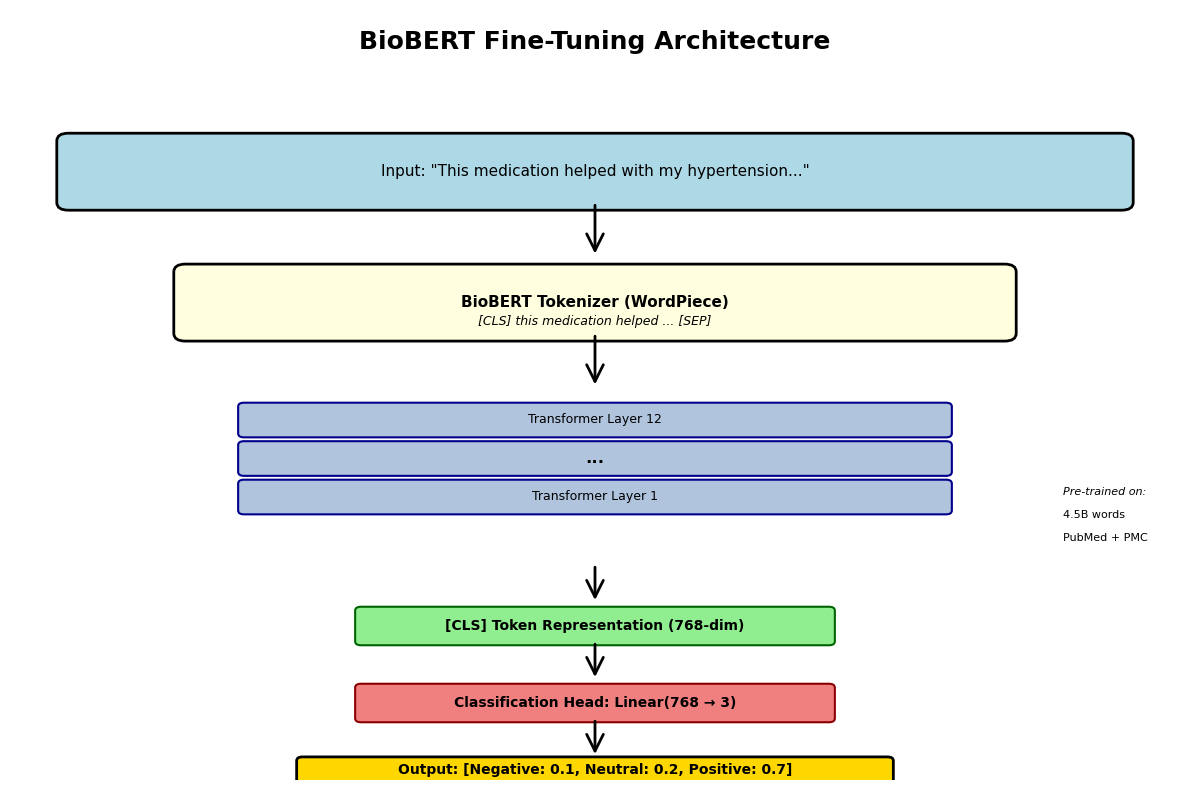

In [30]:
# Create architecture diagram for the report
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'BioBERT Fine-Tuning Architecture', 
        fontsize=18, fontweight='bold', ha='center')

# Input text
input_box = FancyBboxPatch((0.5, 7.5), 9, 0.8, 
                           boxstyle="round,pad=0.1", 
                           edgecolor='black', facecolor='lightblue', linewidth=2)
ax.add_patch(input_box)
ax.text(5, 7.9, 'Input: "This medication helped with my hypertension..."', 
        fontsize=11, ha='center', va='center')

# Arrow down
arrow1 = FancyArrowPatch((5, 7.5), (5, 6.8), 
                        arrowstyle='->', mutation_scale=30, linewidth=2, color='black')
ax.add_patch(arrow1)

# Tokenization
token_box = FancyBboxPatch((1.5, 5.8), 7, 0.8, 
                          boxstyle="round,pad=0.1", 
                          edgecolor='black', facecolor='lightyellow', linewidth=2)
ax.add_patch(token_box)
ax.text(5, 6.2, 'BioBERT Tokenizer (WordPiece)', 
        fontsize=11, ha='center', va='center', fontweight='bold')
ax.text(5, 5.95, '[CLS] this medication helped ... [SEP]', 
        fontsize=9, ha='center', va='center', style='italic')

# Arrow down
arrow2 = FancyArrowPatch((5, 5.8), (5, 5.1), 
                        arrowstyle='->', mutation_scale=30, linewidth=2, color='black')
ax.add_patch(arrow2)

# BioBERT Encoder (12 layers)
for i in range(3):
    layer_box = FancyBboxPatch((2, 4.5-i*0.5), 6, 0.35, 
                              boxstyle="round,pad=0.05", 
                              edgecolor='darkblue', facecolor='lightsteelblue', linewidth=1.5)
    ax.add_patch(layer_box)
    if i == 0:
        ax.text(5, 4.68-i*0.5, f'Transformer Layer 12', 
                fontsize=9, ha='center', va='center')
    elif i == 1:
        ax.text(5, 4.68-i*0.5, '...', 
                fontsize=12, ha='center', va='center', fontweight='bold')
    else:
        ax.text(5, 4.68-i*0.5, 'Transformer Layer 1', 
                fontsize=9, ha='center', va='center')

# Pre-training info
ax.text(9, 3.7, 'Pre-trained on:', fontsize=8, ha='left', style='italic')
ax.text(9, 3.4, '4.5B words', fontsize=8, ha='left')
ax.text(9, 3.1, 'PubMed + PMC', fontsize=8, ha='left')

# Arrow down
arrow3 = FancyArrowPatch((5, 2.8), (5, 2.3), 
                        arrowstyle='->', mutation_scale=30, linewidth=2, color='black')
ax.add_patch(arrow3)

# [CLS] token extraction
cls_box = FancyBboxPatch((3, 1.8), 4, 0.4, 
                        boxstyle="round,pad=0.05", 
                        edgecolor='darkgreen', facecolor='lightgreen', linewidth=1.5)
ax.add_patch(cls_box)
ax.text(5, 2.0, '[CLS] Token Representation (768-dim)', 
        fontsize=10, ha='center', va='center', fontweight='bold')

# Arrow down
arrow4 = FancyArrowPatch((5, 1.8), (5, 1.3), 
                        arrowstyle='->', mutation_scale=30, linewidth=2, color='black')
ax.add_patch(arrow4)

# Classification head
head_box = FancyBboxPatch((3, 0.8), 4, 0.4, 
                         boxstyle="round,pad=0.05", 
                         edgecolor='darkred', facecolor='lightcoral', linewidth=1.5)
ax.add_patch(head_box)
ax.text(5, 1.0, 'Classification Head: Linear(768 → 3)', 
        fontsize=10, ha='center', va='center', fontweight='bold')

# Arrow down
arrow5 = FancyArrowPatch((5, 0.8), (5, 0.3), 
                        arrowstyle='->', mutation_scale=30, linewidth=2, color='black')
ax.add_patch(arrow5)

# Output
output_box = FancyBboxPatch((2.5, 0), 5, 0.25, 
                           boxstyle="round,pad=0.05", 
                           edgecolor='black', facecolor='gold', linewidth=2)
ax.add_patch(output_box)
ax.text(5, 0.125, 'Output: [Negative: 0.1, Neutral: 0.2, Positive: 0.7]', 
        fontsize=10, ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('biobert_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Architecture diagram saved as 'biobert_architecture.png'")
plt.show()